### ALGORITHM DEVELOPMENT
#### This notebook documents the development of algorithms to estimate uroflowmetry waveforms from scale measurements.

  ---

#### PRELIMINARY SETTINGS

In [1]:

# REQUIRED
    # for plotting with hover reveal of x, y values install of mlpcursor is required (pip install mplcursors)


import pandas as pd
import os
import numpy as np

filepath_str = r"C:\KaisDir\Dropbox\K0_Work\00_Elbeon\Elbeon_SkunkWorxx\UrineFlowmeter\0_Github\uroflowmetry\Uroflow_Studio\DataLogs"
filename_str = "CONSTANT_HIFLO_BOTTLEHIGH_UroData_13012026_2043.csv"

# Construct the full file path
full_filepath_str = os.path.join(filepath_str, filename_str)


Plotting function

In [68]:
import matplotlib.pyplot as plt

def plot_2signals(signal1_df,
                  signal1_column_name,
                  signal1_y_label,
                  signal2_df=None,
                  signal2_column_name=None,
                  signal2_y_label="Signal 2",
                  time_start__sec=None, 
                  time_end__sec=None,
                  signal1_y_min=None, 
                  signal1_y_max=None,
                  signal2_y_min=None, 
                  signal2_y_max=None,
                  signal1_auto_scale=1,
                  signal2_auto_scale=1,
                  plot_title=None,
                  figsize=(10, 6)):
    """
    Plot signal1 and optionally signal2 vs time on the same plot with dual y-axes.
    Signal1 is plotted on the left y-axis, signal2 (if provided) on the right y-axis.
    
    Parameters:
    -----------
    signal1_df : pandas.DataFrame
        DataFrame containing 'Time__sec' and the signal1 column
    signal1_column_name : str
        Name of the column in signal1_df to plot
    signal1_y_label : str
        Label for the left y-axis and legend entry for signal1
    signal2_df : pandas.DataFrame, optional
        DataFrame containing 'Time__sec' and the signal2 column (None = plot only signal1)
    signal2_column_name : str, optional
        Name of the column in signal2_df to plot (None = plot only signal1)
    signal2_y_label : str
        Label for the right y-axis and legend entry for signal2 (only used if signal2 is provided)
    time_start__sec : float, optional
        Start time for plotting (None = use all data from start)
    time_end__sec : float, optional
        End time for plotting (None = use all data to end)
    signal1_y_min : float, optional
        Minimum y-axis value for signal1 plot (only used if signal1_auto_scale=0)
    signal1_y_max : float, optional
        Maximum y-axis value for signal1 plot (only used if signal1_auto_scale=0)
    signal2_y_min : float, optional
        Minimum y-axis value for signal2 plot (only used if signal2_auto_scale=0)
    signal2_y_max : float, optional
        Maximum y-axis value for signal2 plot (only used if signal2_auto_scale=0)
    signal1_auto_scale : int
        1 = auto-scale signal1 y-axis, 0 = use manual limits
    signal2_auto_scale : int
        1 = auto-scale signal2 y-axis, 0 = use manual limits
    figsize : tuple
        Figure size (width, height) in inches
    
    Examples:
    --------
    # Plot only signal1 (weight)
    plot_signal1_and_signal2(data_df, 'Weight__g', 'Weight (g)')
    
    # Plot signal1 and signal2 (weight and flow)
    plot_signal1_and_signal2(data_df, 'Weight__g', 'Weight (g)',
                             data_df, 'Flow__mLPmin', 'Flow (mL/min)')
    
    # Plot specific time range with manual signal1 limits
    plot_2signal(data_df, 'Weight__g', 'Weight (g)',
                             time_start__sec=10.0, 
                             time_end__sec=50.0,
                             signal1_y_min=750.0,
                             signal1_y_max=760.0,
                             signal1_auto_scale=0)
    
    # Both signals with manual limits
    plot_2signal(data_df, 'Weight__g', 'Weight (g)',
                             data_df, 'Flow__mLPmin', 'Flow (mL/min)',
                             time_start__sec=0.0,
                             time_end__sec=100.0,
                             signal1_y_min=700.0,
                             signal1_y_max=800.0,
                             signal2_y_min=-10.0,
                             signal2_y_max=50.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=0)
    """
    
    # Filter signal1 data based on time range (if specified)
    signal1_filtered_df = signal1_df.copy()
    if time_start__sec is not None:
        signal1_filtered_df = signal1_filtered_df[signal1_filtered_df['Time__sec'] >= time_start__sec]
    if time_end__sec is not None:
        signal1_filtered_df = signal1_filtered_df[signal1_filtered_df['Time__sec'] <= time_end__sec]
    
    # Create figure and first axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot signal1 on left y-axis
    color1 = 'tab:blue'
    ax1.set_xlabel('Time (sec)', fontsize=12)
    ax1.set_ylabel(signal1_y_label, color=color1, fontsize=12)
    line1 = ax1.plot(signal1_filtered_df['Time__sec'], signal1_filtered_df[signal1_column_name], 
                     color=color1, linewidth=1.5, label=signal1_y_label)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    
    # Set signal1 y-axis limits based on switch
    if signal1_auto_scale == 0:
        if signal1_y_min is not None and signal1_y_max is not None:
            ax1.set_ylim(signal1_y_min, signal1_y_max)
    
    # Initialize legend with signal1
    lines = line1
    labels = [signal1_y_label]
    
    # Plot signal2 only if provided
    if signal2_df is not None and signal2_column_name is not None:
        # Filter signal2 data based on time range (if specified)
        signal2_filtered_df = signal2_df.copy()
        if time_start__sec is not None:
            signal2_filtered_df = signal2_filtered_df[signal2_filtered_df['Time__sec'] >= time_start__sec]
        if time_end__sec is not None:
            signal2_filtered_df = signal2_filtered_df[signal2_filtered_df['Time__sec'] <= time_end__sec]
        
        # Create second y-axis for signal2
        ax2 = ax1.twinx()
        color2 = 'tab:red'
        ax2.set_ylabel(signal2_y_label, color=color2, fontsize=12)
        line2 = ax2.plot(signal2_filtered_df['Time__sec'], signal2_filtered_df[signal2_column_name], 
                         color=color2, linewidth=1.5, label=signal2_y_label)
        ax2.tick_params(axis='y', labelcolor=color2)
        
        # Set signal2 y-axis limits based on switch
        if signal2_auto_scale == 0:
            if signal2_y_min is not None and signal2_y_max is not None:
                ax2.set_ylim(signal2_y_min, signal2_y_max)
        
        # Update legend to include both signals
        lines = line1 + line2
        labels = [signal1_y_label, signal2_y_label]
    
    # Add legend
    ax1.legend(lines, labels, loc='upper left')
    
    # Add title
    if(plot_title is None):
        if signal2_df is not None and signal2_column_name is not None:
            plt.title('Signal 1 and Signal 2 vs Time', fontsize=14)
        else:
            plt.title('Signal 1 vs Time', fontsize=14)
    else:
        plt.title(plot_title, fontsize=14)  
    
    # Adjust spacing
    plt.tight_layout()
    
    # Display the plot
    plt.show()
    
    # if signal2_df is not None and signal2_column_name is not None:
    #    return fig, (ax1, ax2)
    #else:
    #    return fig, ax1

### LOADING DATA

In [8]:
data_df = pd.read_csv(full_filepath_str)


This is the dataframe's structure:  

In [9]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Time__sec                 990 non-null    float64
 1   Weight__g                 990 non-null    float64
 2   Flow__mLPmin              990 non-null    float64
 3   FlowsensorError_Air       990 non-null    int64  
 4   FlowsensorError_Overflow  990 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 38.8 KB


An initial look at the data:

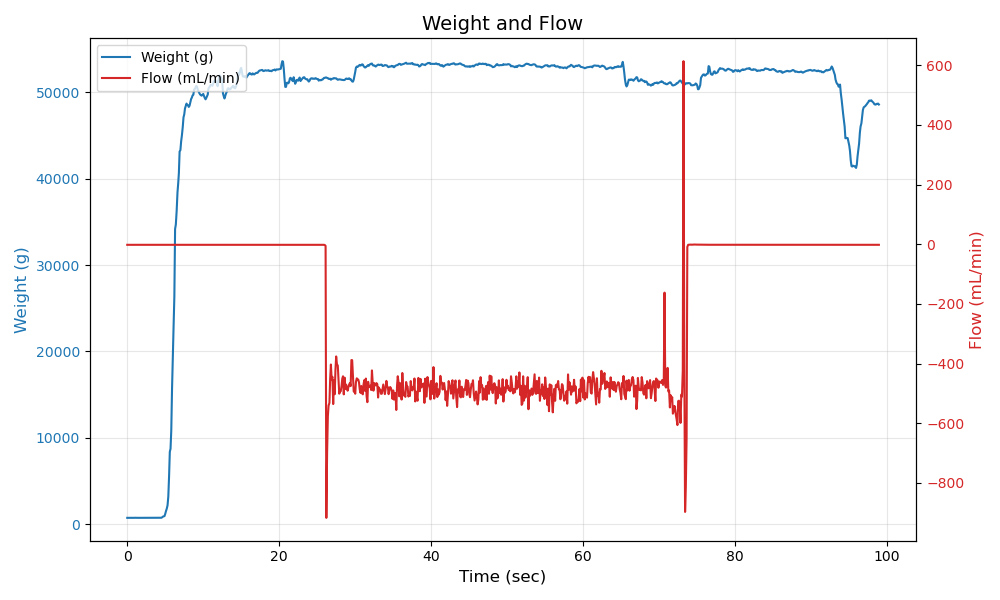

In [73]:

plot_2signals(data_df, 'Weight__g', 'Weight (g)',
                             data_df, 'Flow__mLPmin', 'Flow (mL/min)',
                             time_start__sec=0.0,
                             time_end__sec=100.0,
                             signal1_y_min=700.0,
                             signal1_y_max=800.0,
                             signal2_y_min=-10.0,
                             signal2_y_max=50.0,
                             signal1_auto_scale=1,
                             signal2_auto_scale=1,
                             plot_title="Weight and Flow")



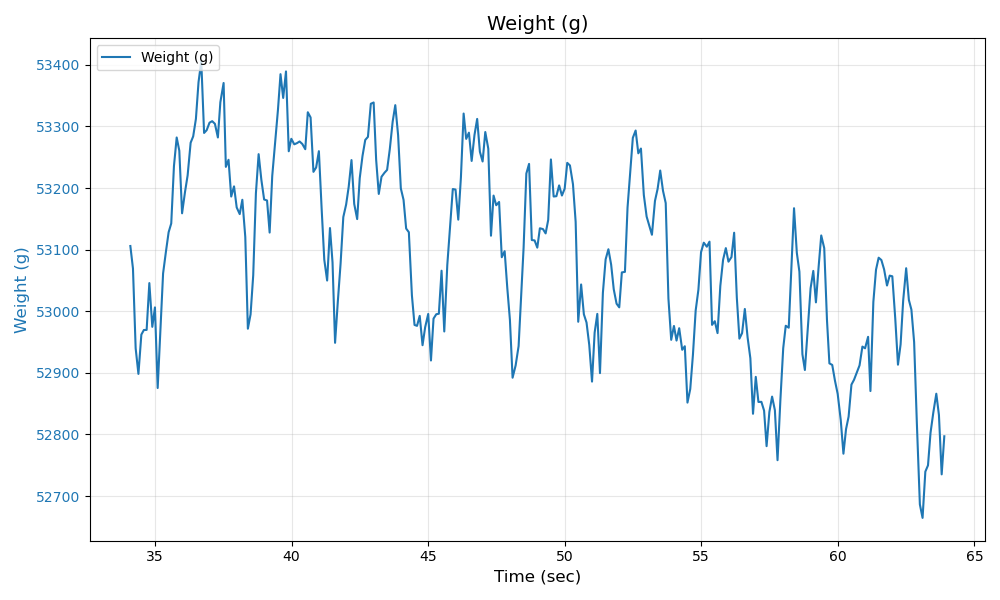

In [74]:
plot_2signals(data_df, 'Weight__g', 'Weight (g)',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=700.0,
                             signal1_y_max=800.0,
                             signal2_y_min=-10.0,
                             signal2_y_max=50.0,
                             signal1_auto_scale=1,
                             signal2_auto_scale=1,
                             plot_title="Weight (g)")

Here is the spectrogram (FFT) of that signal:

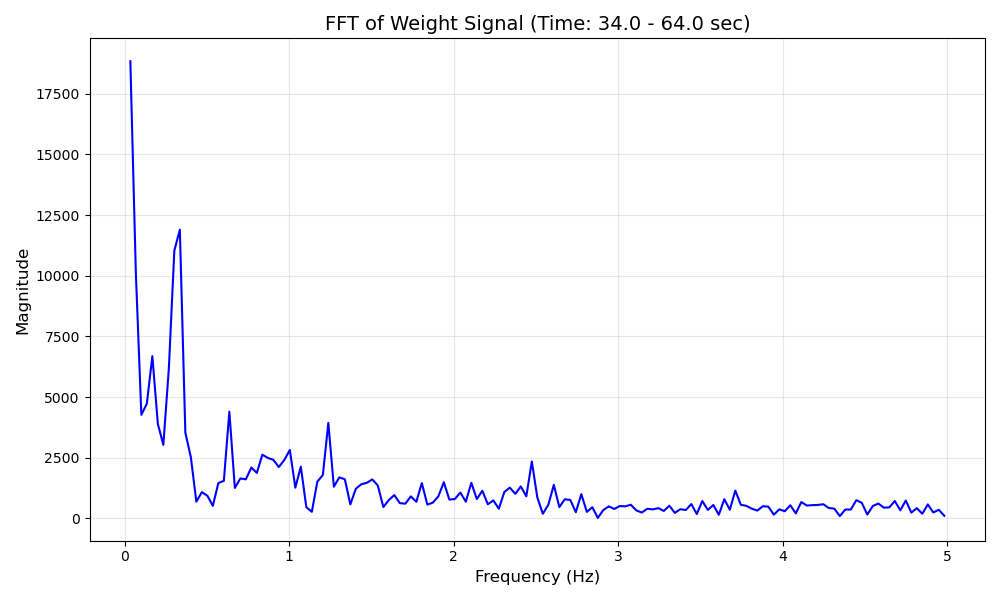

In [17]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Time range for FFT analysis
fft_time_start__sec = 34.0
fft_time_end__sec = 64.0

# Filter data for the specified time range
mask = (data_df['Time__sec'] >= fft_time_start__sec) & (data_df['Time__sec'] <= fft_time_end__sec)
data_fft_df = data_df[mask].copy()

# Extract time and weight signals
time__sec = data_fft_df['Time__sec'].values
weight__g = data_fft_df['Weight__g'].values

# Calculate sampling rate
if len(time__sec) > 1:
    dt__sec = np.mean(np.diff(time__sec))
    sampling_rate__Hz = 1.0 / dt__sec
else:
    print("Warning: Not enough data points for FFT")
    sampling_rate__Hz = 1.0

# Number of data points
N = len(weight__g)

# Perform FFT
fft_result = np.fft.rfft(weight__g)
magnitude = np.abs(fft_result)
frequencies__Hz = np.fft.rfftfreq(N, dt__sec)

# Exclude 0 Hz
frequencies__Hz_no_dc = frequencies__Hz[1:]
magnitude_no_dc = magnitude[1:]

# Plot the FFT
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies__Hz_no_dc, magnitude_no_dc, 'b-', linewidth=1.5)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title(f'FFT of Weight Signal (Time: {fft_time_start__sec:.1f} - {fft_time_end__sec:.1f} sec)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Low Pass Filtered Version (with an initialization at a specific time step, init_time__sec)

In [61]:
# Lowpass filter parameter
alpha = 0.99  # Adjust this value (0 < alpha < 1)

# Time point for filter initialization
init_time__sec = 34.0  # Time point to initialize the filter

# Get weight values as numpy array
weight__g = data_df['Weight__g'].values
time__sec = data_df['Time__sec'].values

# Find the index closest to the initialization time
init_index = np.argmin(np.abs(time__sec - init_time__sec))
init_time_actual__sec = time__sec[init_index]

# Initialize filtered array
lp_weight__g = np.zeros_like(weight__g)

# Initialize filter at the specified time point
lp_weight__g[init_index] = weight__g[init_index]

# Apply lowpass filter forward from initialization point
for n in range(init_index + 1, len(lp_weight__g)):
    lp_weight__g[n] = alpha * lp_weight__g[n-1] + (1 - alpha) * weight__g[n]

# For values before initialization point, you can either:
# Option 1: Use original values (unfiltered)
lp_weight__g[:init_index] = weight__g[:init_index]

# Option 2: Leave as NaN (commented out - uncomment to use this instead)
# lp_weight__g[:init_index] = np.nan

# Add the filtered signal as a new column to the dataframe
data_df['lp_Weight__g'] = lp_weight__g

# Display information about initialization
#print(f"Filter initialized at time: {init_time_actual__sec:.3f} sec (requested: {init_time__sec:.3f} sec)")
#print(f"Initialization index: {init_index}")
#print(f"Initial weight value: {weight__g[init_index]:.2f} g")

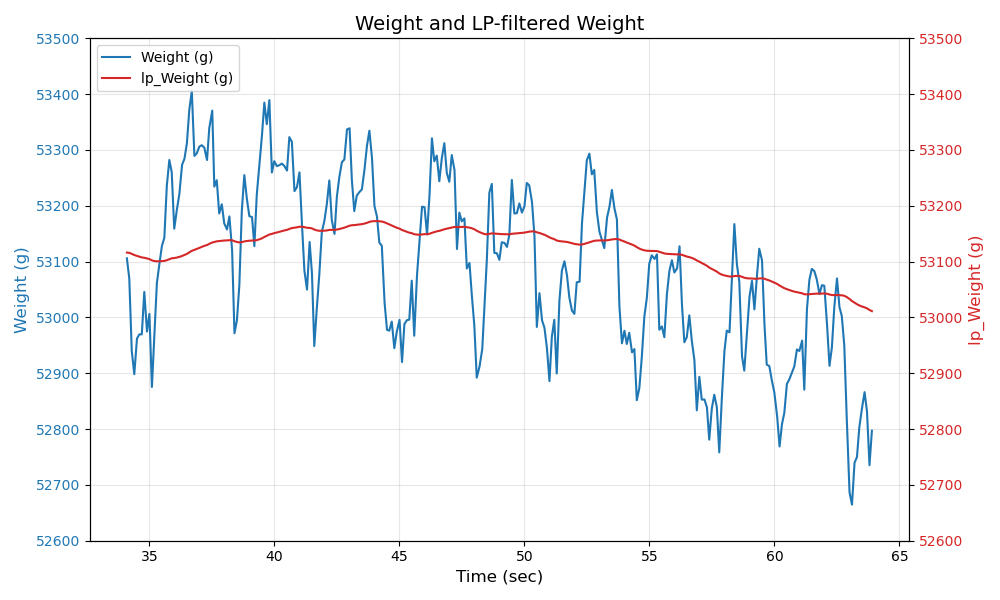

In [75]:
plot_2signals(data_df, 'Weight__g', 'Weight (g)',
              data_df, 'lp_Weight__g', 'lp_Weight (g)',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=0,
                             plot_title=f"Weight and LP-filtered Weight")

## SIGNAL BASED ON DETECTED PEAKS ##
First, let's create a signal that hugs the weight signal as it increases and decays as the weight signal decreases.
The signal is governed by "beta" which is from a range of 0...1 (the small the faster is the decay)

In [90]:
beta = 0.99990  # Decay factor (0 < beta <= 1)

import numpy as np

# Parameters
init_time__sec = 0.0  # Time point to initialize signal2
#beta = 0.99990  # Decay factor (0 < beta <= 1)
# Higher beta = slower decay
# Lower beta = faster decay

# Get weight and time values
time__sec = data_df['Time__sec'].values
weight__g = data_df['Weight__g'].values

# Find the index closest to the initialization time
init_index = np.argmin(np.abs(time__sec - init_time__sec))
init_time_actual__sec = time__sec[init_index]

# Initialize signal2 array
signal2__g = np.zeros_like(weight__g)

# Initialize signal2 at the specified time point
signal2__g[init_index] = weight__g[init_index]

# Process data forward from initialization point
for n in range(init_index + 1, len(signal2__g)):
    if weight__g[n] > signal2__g[n-1]:
        # If weight is larger, signal2 tracks the weight
        signal2__g[n] = weight__g[n]
    else:
        # If weight is smaller, signal2 decays exponentially
        signal2__g[n] = beta * signal2__g[n-1]

# For values before initialization point, you can either:
# Option 1: Use original weight values (unfiltered)
signal2__g[:init_index] = weight__g[:init_index]

# Option 2: Leave as NaN (commented out - uncomment to use this instead)
# signal2__g[:init_index] = np.nan

# Add the signal2 as a new column to the dataframe
data_df['signal2__g'] = signal2__g


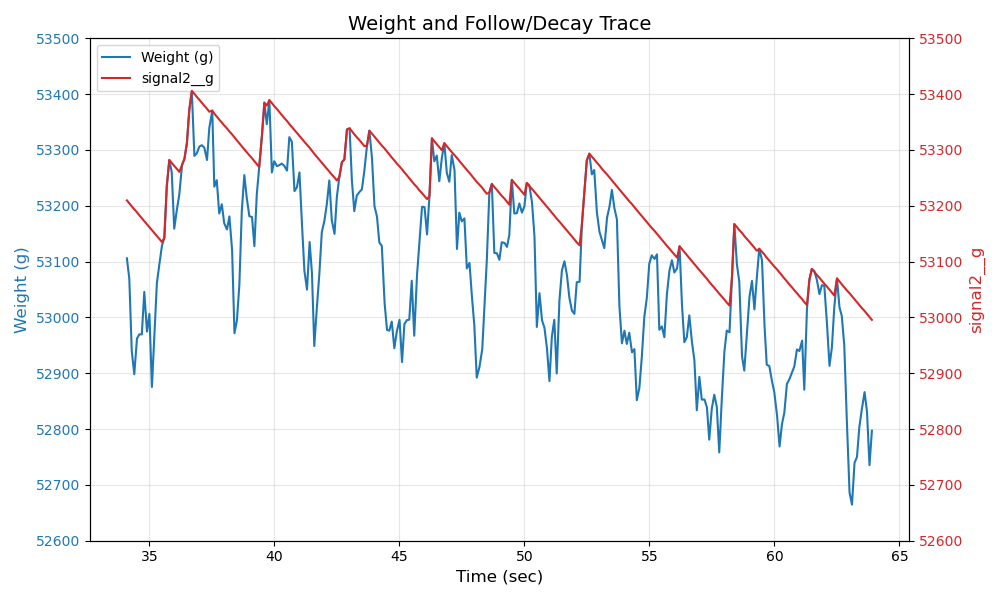

In [91]:
plot_2signals(data_df, 'Weight__g', 'Weight (g)',
              data_df, 'signal2__g', 'signal2__g',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=0,
                             plot_title="Weight and Follow/Decay Trace")

Then, let's create a signal that goes from peak to peak, but has the same time resolution as the original weight signal.

In [52]:
import numpy as np

# Get the signals
time__sec = data_df['Time__sec'].values
weight__g = data_df['Weight__g'].values
signal2__g = data_df['signal2__g'].values

# Find peak indicators more explicitly
# A peak indicator is where signal2 equals weight (peak point) 
# and the next point starts decaying
peak_indicator_indices = []

# Find initialization index (assuming same init_time__sec as before)
init_time__sec = 0.0  # Adjust if different
init_index = np.argmin(np.abs(time__sec - init_time__sec))
peak_indicator_indices.append(init_index)

# Find subsequent peaks
for n in range(init_index + 1, len(signal2__g)):
    # Check if this is a peak (signal2 equals weight) and next point will decay
    is_peak = (abs(signal2__g[n] - weight__g[n]) < 1e-6)  # Signal2 equals weight
    if n < len(signal2__g) - 1:
        will_decay = (weight__g[n+1] < signal2__g[n])  # Next weight is lower
        if is_peak and will_decay:
            peak_indicator_indices.append(n)

# Create signal3 with straight lines connecting peak indicators
signal3__g = np.zeros_like(weight__g)

# For each segment between consecutive peak indicators
for i in range(len(peak_indicator_indices) - 1):
    start_idx = peak_indicator_indices[i]
    end_idx = peak_indicator_indices[i + 1]
    
    start_value = signal2__g[start_idx]
    end_value = signal2__g[end_idx]
    
    # Linear interpolation
    num_points = end_idx - start_idx + 1
    signal3__g[start_idx:end_idx + 1] = np.linspace(start_value, end_value, num_points)

# Handle last segment
if len(peak_indicator_indices) > 0:
    last_idx = peak_indicator_indices[-1]
    if last_idx < len(signal3__g) - 1:
        # Extend with last peak value
        signal3__g[last_idx:] = signal2__g[last_idx]

# Handle values before first peak
if len(peak_indicator_indices) > 0:
    first_idx = peak_indicator_indices[0]
    if first_idx > 0:
        signal3__g[:first_idx] = signal2__g[first_idx]

# Add to dataframe
data_df['signal3__g'] = signal3__g

# Display information
#print(f"Number of peak indicators: {len(peak_indicator_indices)}")
#print(f"Peak indicator indices: {peak_indicator_indices[:10]}")

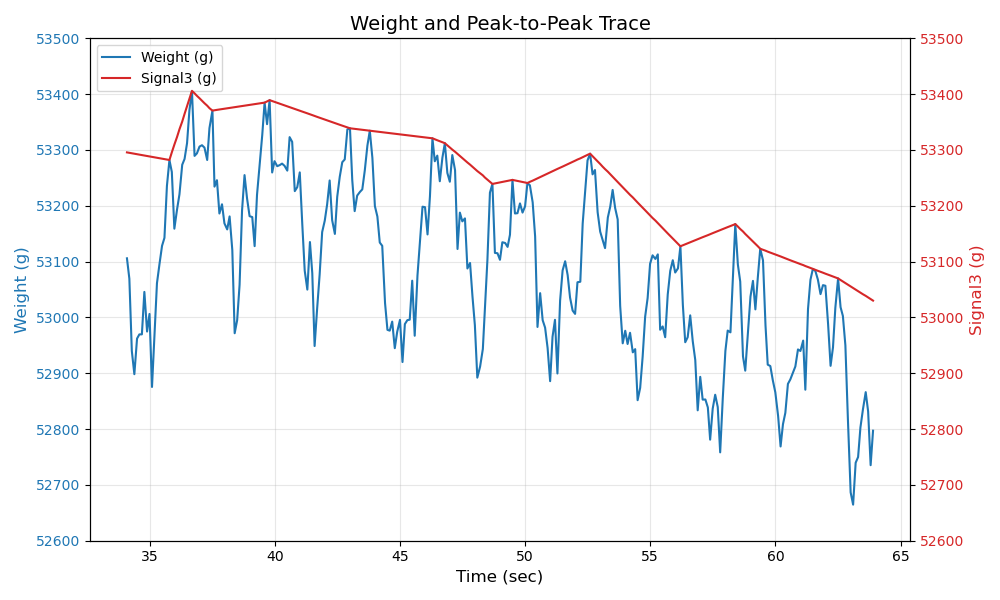

In [92]:


plot_2signals(data_df, 'Weight__g', 'Weight (g)',
              data_df, 'signal3__g', 'Signal3 (g)',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=0,
                             plot_title="Weight and Peak-to-Peak Trace")



Low-Pass filtering that peak-to-peak signal should give us a reasonably smooth signal showing the general trend:

In [93]:
alpha3 = 0.8  # Adjust this value (0 < alpha < 1)
import numpy as np

# Lowpass filter parameter

# Higher alpha = more smoothing (slower response)
# Lower alpha = less smoothing (faster response)

# Time point for filter initialization
init_time__sec = 34.0  # Time point to initialize the filter

# Get signal3 values as numpy array
signal3__g = data_df['signal3__g'].values
time__sec = data_df['Time__sec'].values

# Find the index closest to the initialization time
init_index = np.argmin(np.abs(time__sec - init_time__sec))
init_time_actual__sec = time__sec[init_index]

# Initialize filtered array
lp_signal3__g = np.zeros_like(signal3__g)

# Initialize filter at the specified time point
lp_signal3__g[init_index] = signal3__g[init_index]

# Apply lowpass filter forward from initialization point
for n in range(init_index + 1, len(lp_signal3__g)):
    lp_signal3__g[n] = alpha3 * lp_signal3__g[n-1] + (1 - alpha3) * signal3__g[n]

# For values before initialization point, you can either:
# Option 1: Use original signal3 values (unfiltered)
lp_signal3__g[:init_index] = signal3__g[:init_index]

# Option 2: Leave as NaN (commented out - uncomment to use this instead)
# lp_signal3__g[:init_index] = np.nan

# Add the filtered signal as a new column to the dataframe
data_df['lp_signal3__g'] = lp_signal3__g

# Display information about initialization
#print(f"Filter initialized at time: {init_time_actual__sec:.3f} sec (requested: {init_time__sec:.3f} sec)")
#print(f"Initialization index: {init_index}")
#print(f"Initial signal3 value: {signal3__g[init_index]:.2f} g")
#print(f"Alpha (smoothing factor): {alpha}")
#print(f"\nFirst 10 values after initialization:")
#print(data_df[['Time__sec', 'signal3__g', 'lp_signal3__g']].iloc[init_index:init_index+10])

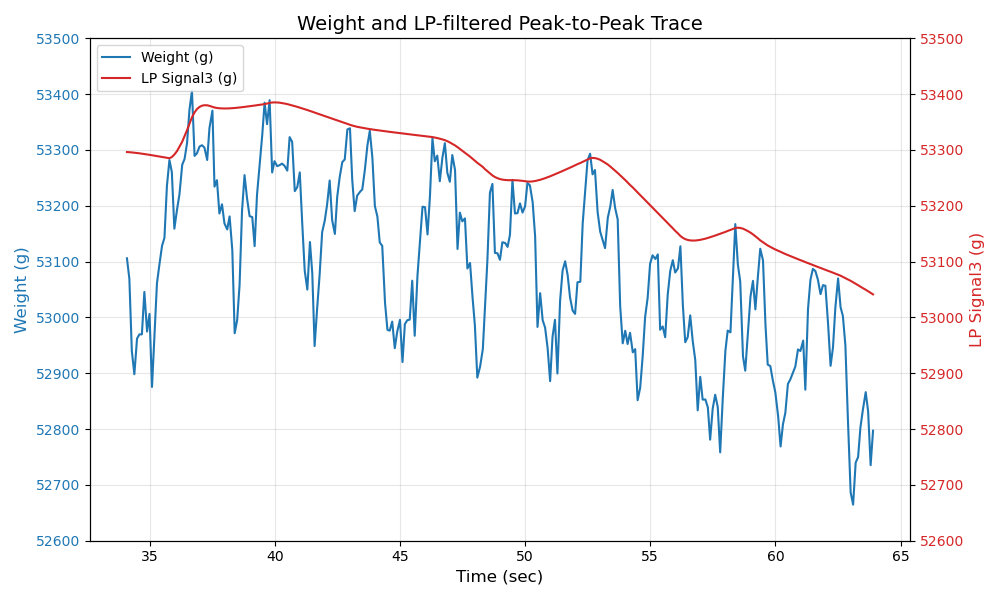

In [94]:

plot_2signals(data_df, 'Weight__g', 'Weight (g)',
              data_df, 'lp_signal3__g', 'LP Signal3 (g)',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=0,
                             plot_title="Weight and LP-filtered Peak-to-Peak Trace")

In [97]:
import numpy as np

# Parameters for piecewise linear regression
regression_start_time__sec = 0.0
piece_length__sec = 10.0

# Get the signals
time__sec = data_df['Time__sec'].values
lp_signal3__g = data_df['lp_signal3__g'].values

# Find the index closest to the start time
start_index = np.argmin(np.abs(time__sec - regression_start_time__sec))

# Initialize arrays
slope__g_per_sec = np.full(len(time__sec), np.nan)
r_squared = np.full(len(time__sec), np.nan)

# Process data in pieces
current_index = start_index

while current_index < len(time__sec):
    # Find end time for this piece
    piece_end_time__sec = time__sec[current_index] + piece_length__sec
    
    # Find indices within this piece
    piece_mask = (time__sec >= time__sec[current_index]) & (time__sec < piece_end_time__sec)
    piece_indices = np.where(piece_mask)[0]
    
    if len(piece_indices) < 2:
        break
    
    # Extract valid data
    piece_time = time__sec[piece_indices]
    piece_signal = lp_signal3__g[piece_indices]
    
    valid_mask = ~np.isnan(piece_signal)
    if np.sum(valid_mask) < 2:
        current_index = piece_indices[-1] + 1
        continue
    
    piece_time_valid = piece_time[valid_mask]
    piece_signal_valid = piece_signal[valid_mask]
    
    # Linear regression using numpy.polyfit (degree 1 = linear)
    coeffs = np.polyfit(piece_time_valid, piece_signal_valid, 1)
    slope = coeffs[0]
    
    # Calculate r^2
    y_pred = np.polyval(coeffs, piece_time_valid)
    ss_res = np.sum((piece_signal_valid - y_pred) ** 2)
    ss_tot = np.sum((piece_signal_valid - np.mean(piece_signal_valid)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Assign to all points in this piece
    slope__g_per_sec[piece_indices] = slope
    r_squared[piece_indices] = r2
    
    current_index = piece_indices[-1] + 1

# Add columns to dataframe
data_df['slope__g_per_sec'] = slope__g_per_sec
data_df['r_squared'] = r_squared

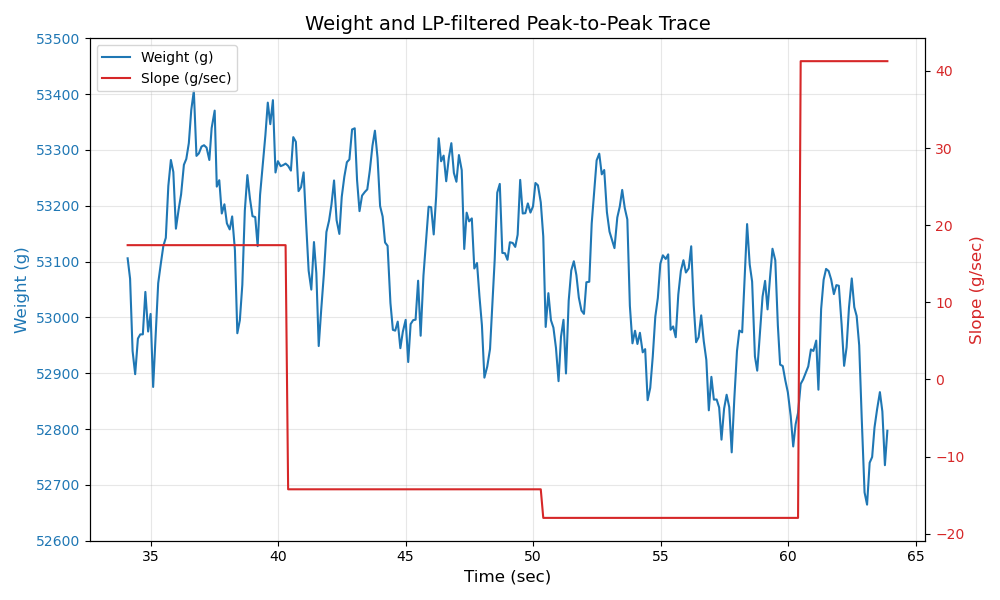

In [98]:
plot_2signals(data_df, 'Weight__g', 'Weight (g)',
              data_df, 'slope__g_per_sec', 'Slope (g/sec)',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=1,
                             plot_title="Weight and LP-filtered Peak-to-Peak Trace")

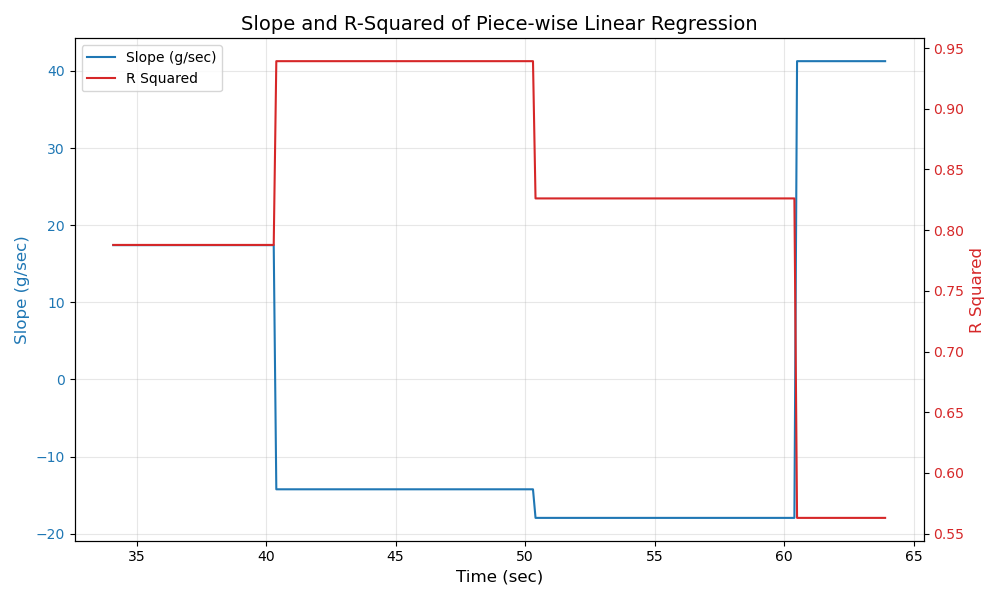

In [99]:
plot_2signals(data_df, 'slope__g_per_sec', 'Slope (g/sec)',
              data_df, 'r_squared', 'R Squared',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=1,
                             signal2_auto_scale=1,
                             plot_title="Slope and R-Squared of Piece-wise Linear Regression")

In [ ]:
plot_2signals(data_df, 'Weight__g', 'Weight (g)',
              data_df, 'r_squared', 'R Squared',
                             time_start__sec=34.0,
                             time_end__sec=64.0,
                             signal1_y_min=52600.0,
                             signal1_y_max=53500.0,
                             signal2_y_min=52600.0,
                             signal2_y_max=53500.0,
                             signal1_auto_scale=0,
                             signal2_auto_scale=1,
                             plot_title="Weight and LP-filtered Peak-to-Peak Trace")